# Ablation Study — CartPole-v1

**Three ablations, one variable isolated at a time:**

| Ablation | Variable | Fixed |
|---|---|---|
| **A1 — Precedence ON vs OFF** | presence of WM verification | algorithm=DQN, config=best |
| **A2 — World Model Config** | C1 vs C2 vs C3 | algorithm=DQN+PPO, strategy=combined |
| **A3 — Verification Strategy** | safety vs lookahead vs combined | algorithm=DQN, config=best |

**Data source:** loads directly from `eval_plots_CartPole/cartpole_eval_results.json`  
(produced by `evaluation_CartPole.ipynb`) — no re-training, no re-evaluation.

**Outputs:** bar charts, delta tables, one combined figure per ablation.

## 1. Imports & Load Eval Results

In [2]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

EVAL_JSON   = "../Evaluation/eval_plots_CartPole/cartpole_eval_results.json"
PLOT_DIR    = "ablation_plots_CartPole"
SOLVE_THRESH = 475.0
os.makedirs(PLOT_DIR, exist_ok=True)

with open(EVAL_JSON) as f:
    ev = json.load(f)

perf   = ev["performance"]        # agent → {mean_reward, std_reward, ...}
samp   = ev["sample_efficiency"]  # agent → episode_number (-1 = never)
stab   = ev["stability"]          # agent → {mean, std}
robust = ev["robustness"]         # agent → {sigma → mean_reward}

# ── Helper: pull a scalar metric safely ──────────────────────────────────────
def get(agent, metric, default=float('nan')):
    if metric == "mean_reward":
        return perf.get(agent, {}).get("mean_reward", default)
    if metric == "std_reward":
        return perf.get(agent, {}).get("std_reward", default)
    if metric == "episodes_to_solve":
        v = samp.get(agent, -1)
        return float(v) if v and v > 0 else float('nan')
    if metric == "train_std":
        return stab.get(agent, {}).get("std", default)
    if metric.startswith("robust_"):
        sigma = metric.split("_")[1]   # e.g. "robust_0.1" → "0.1"
        return robust.get(agent, {}).get(sigma, default)
    return default

ALL_AGENTS = list(perf.keys())
print(f"✅ Loaded eval results from: {EVAL_JSON}")
print(f"   Agents found: {ALL_AGENTS}")


✅ Loaded eval results from: ../Evaluation/eval_plots_CartPole/cartpole_eval_results.json
   Agents found: ['DQN baseline', 'PPO baseline', 'PPO+Prec C1', 'PPO+Prec C2', 'PPO+Prec C3']


## 2. Ablation A1 — Precedence ON vs OFF

**Question:** Does adding the Precedence Network help at all?

Compare each algorithm against its own baseline:
- DQN baseline  ←→  DQN+Prec (best config)
- PPO baseline  ←→  PPO+Prec (best config)

Metric: mean reward, episodes-to-solve, robustness at σ=0.1

In [ ]:
# ── Identify best precedence config per algorithm ────────────────────────────
def best_config(prefix):
    """Return the agent name with highest mean reward among prefix+C1/C2/C3."""
    candidates = [f"{prefix} C{c}" for c in [1,2,3]]
    valid = [(a, get(a,"mean_reward")) for a in candidates if a in perf]
    if not valid:
        return None, float('nan')
    return max(valid, key=lambda x: x[1])

best_dqn_prec, best_dqn_val = best_config("DQN+Prec")
best_ppo_prec, best_ppo_val = best_config("PPO+Prec")
print(f"Best DQN+Prec : {best_dqn_prec}  (mean={best_dqn_val:.2f})")
print(f"Best PPO+Prec : {best_ppo_prec}  (mean={best_ppo_val:.2f})")

METRICS_A1 = ["mean_reward", "episodes_to_solve", "train_std", "robust_0.1"]
LABELS_A1  = ["Mean Reward", "Episodes to Solve", "Train Std (last 50)", "Robust σ=0.1"]

pairs = [
    ("DQN baseline", best_dqn_prec, "DQN"),
    ("PPO baseline", best_ppo_prec, "PPO"),
]

rows = []
for baseline, prec, algo in pairs:
    if prec is None:
        continue
    row = {"Algorithm": algo}
    for m, lbl in zip(METRICS_A1, LABELS_A1):
        b_val = get(baseline, m)
        p_val = get(prec, m)
        # For episodes_to_solve and train_std: lower is better → Δ = baseline - prec
        # For mean_reward and robust: higher is better → Δ = prec - baseline
        if m in ("episodes_to_solve", "train_std"):
            delta = b_val - p_val
            sign  = "↓ better"
        else:
            delta = p_val - b_val
            sign  = "↑ better"
        row[f"{lbl} (baseline)"] = f"{b_val:.2f}" if not np.isnan(b_val) else "N/A"
        row[f"{lbl} (prec)"]     = f"{p_val:.2f}" if not np.isnan(p_val) else "N/A"
        row[f"Δ ({sign})"]       = f"{delta:+.2f}" if not np.isnan(delta) else "N/A"
    rows.append(row)

df_a1 = pd.DataFrame(rows).set_index("Algorithm")
try:
    from IPython.display import display; display(df_a1.T)
except Exception:
    print(df_a1.T.to_string())


Best DQN+Prec : None  (mean=nan)
Best PPO+Prec : PPO+Prec C1  (mean=nan)


Algorithm,PPO
Mean Reward (baseline),N/A
Mean Reward (prec),N/A
Δ (↑ better),-352.92
Episodes to Solve (baseline),N/A
Episodes to Solve (prec),679.00
Δ (↓ better),N/A
Train Std (last 50) (baseline),N/A
Train Std (last 50) (prec),105.03
Robust σ=0.1 (baseline),500.00
Robust σ=0.1 (prec),147.08


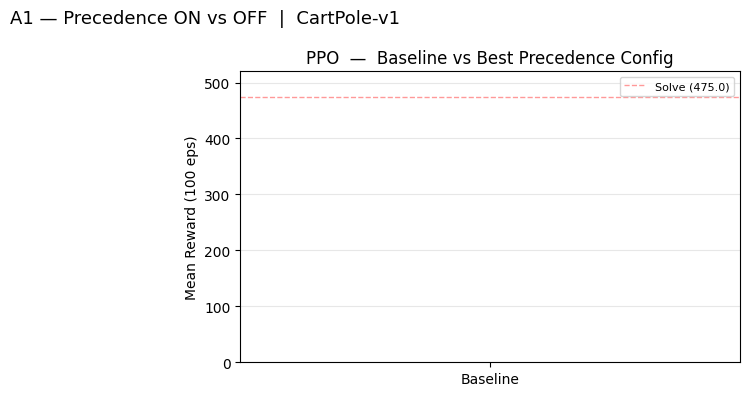

📊 Saved → ablation_plots_CartPole\a1_precedence_on_off.png


In [4]:
# ── A1 Bar chart: mean reward — baseline vs best prec ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("A1 — Precedence ON vs OFF  |  CartPole-v1", fontsize=13)

for ax, (baseline, prec, algo) in zip(axes, pairs):
    if prec is None:
        ax.set_visible(False)
        continue
    labels  = ["Baseline", f"+Precedence\n({prec.split()[-1]})"]
    means   = [get(baseline,"mean_reward"), get(prec,"mean_reward")]
    stds    = [get(baseline,"std_reward"),  get(prec,"std_reward")]
    colors  = ["#aec6e8", "#1f77b4"]
    bars = ax.bar(labels, means, yerr=stds, capsize=6,
                  color=colors, alpha=0.88, width=0.45)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + max(stds)*0.15,
                f"{val:.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.axhline(SOLVE_THRESH, color='red', linestyle='--', alpha=0.4,
               linewidth=1, label=f'Solve ({SOLVE_THRESH})')
    ax.set_ylim(0, 520)
    ax.set_title(f"{algo}  —  Baseline vs Best Precedence Config")
    ax.set_ylabel("Mean Reward (100 eps)")
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
path = os.path.join(PLOT_DIR, "a1_precedence_on_off.png")
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Saved → {path}")


## 3. Ablation A2 — World Model Configuration (C1 vs C2 vs C3)

**Question:** Does the world model formulation matter?

- **C1** — predict S(t+1) directly (absolute)
- **C2** — predict S(t+2) directly (multi-step)
- **C3** — predict ΔS (delta)

Compare all three within each algorithm, measuring:
mean reward, std, episodes-to-solve, robustness at σ=0.1 and σ=0.2

In [5]:
CONFIGS = [1, 2, 3]
CONFIG_LABELS = ["C1\nS(t+1)", "C2\nS(t+2)", "C3\nΔS"]
ALGOS   = ["DQN", "PPO"]

rows_a2 = []
for algo in ALGOS:
    for cfg in CONFIGS:
        name = f"{algo}+Prec C{cfg}"
        rows_a2.append({
            "Agent"            : name,
            "Algorithm"        : algo,
            "Config"           : f"C{cfg}",
            "Mean Reward"      : get(name, "mean_reward"),
            "Std Reward"       : get(name, "std_reward"),
            "Episodes to Solve": get(name, "episodes_to_solve"),
            "Train Std"        : get(name, "train_std"),
            "Robust σ=0.1"     : get(name, "robust_0.1"),
            "Robust σ=0.2"     : get(name, "robust_0.2"),
        })

df_a2 = pd.DataFrame(rows_a2).set_index("Agent")
try:
    from IPython.display import display; display(df_a2)
except Exception:
    print(df_a2.to_string())


,Algorithm,Config,Mean Reward,Std Reward,Episodes to Solve,Train Std,Robust σ=0.1,Robust σ=0.2
Agent,,,,,,,,
DQN+Prec C1,DQN,C1,NaN,NaN,NaN,91.453335,NaN,NaN
DQN+Prec C2,DQN,C2,NaN,NaN,NaN,80.465965,NaN,NaN
DQN+Prec C3,DQN,C3,NaN,NaN,NaN,90.506311,NaN,NaN
PPO+Prec C1,PPO,C1,NaN,NaN,679.0,105.026854,147.08,117.96
PPO+Prec C2,PPO,C2,NaN,NaN,263.0,98.357717,85.16,88.70
PPO+Prec C3,PPO,C3,NaN,NaN,700.0,93.218453,177.60,126.88


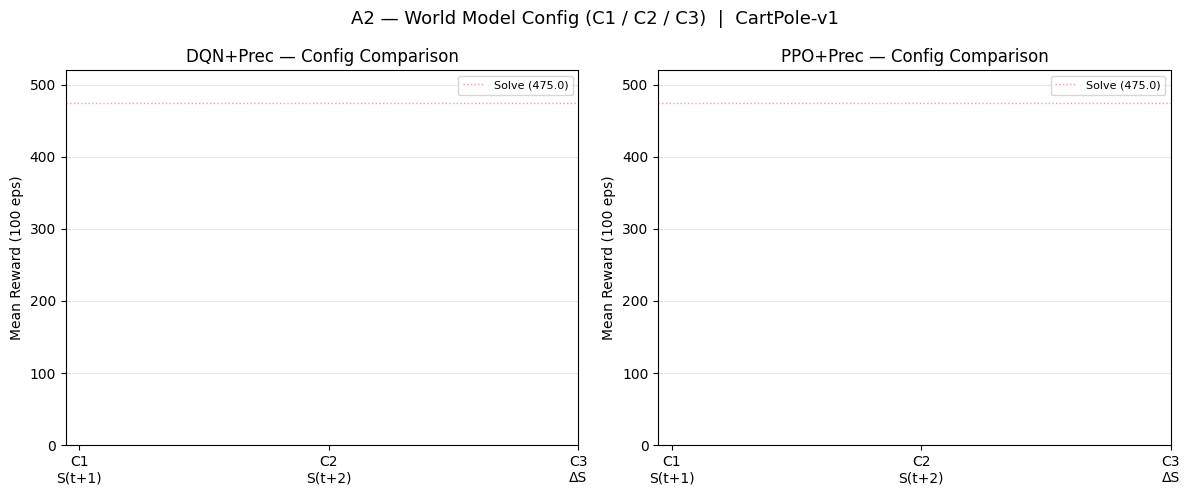

📊 Saved → ablation_plots_CartPole\a2_wm_config.png


In [6]:
# ── A2 Bar chart: mean reward × config × algorithm ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("A2 — World Model Config (C1 / C2 / C3)  |  CartPole-v1", fontsize=13)

x   = np.arange(len(CONFIGS))
w   = 0.5
c1c = "#2ca02c"; c2c = "#17becf"; c3c = "#bcbd22"
cfg_colors = [c1c, c2c, c3c]

for ax, algo in zip(axes, ALGOS):
    means = [get(f"{algo}+Prec C{c}", "mean_reward") for c in CONFIGS]
    stds  = [get(f"{algo}+Prec C{c}", "std_reward")  for c in CONFIGS]
    bars  = ax.bar(x, means, width=w, yerr=stds, capsize=6,
                   color=cfg_colors, alpha=0.88)
    for bar, val, std in zip(bars, means, stds):
        if not np.isnan(val):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height() + std*0.15 + 2,
                    f"{val:.1f}", ha='center', va='bottom',
                    fontsize=10, fontweight='bold')
    # Baseline reference line
    bl_val = get(f"{algo} baseline", "mean_reward")
    if not np.isnan(bl_val):
        ax.axhline(bl_val, color='grey', linestyle='--', linewidth=1.5,
                   label=f"{algo} baseline ({bl_val:.1f})")
    ax.axhline(SOLVE_THRESH, color='red', linestyle=':', alpha=0.4,
               linewidth=1, label=f'Solve ({SOLVE_THRESH})')
    ax.set_xticks(x); ax.set_xticklabels(CONFIG_LABELS, fontsize=10)
    ax.set_ylim(0, 520)
    ax.set_title(f"{algo}+Prec — Config Comparison")
    ax.set_ylabel("Mean Reward (100 eps)")
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
path = os.path.join(PLOT_DIR, "a2_wm_config.png")
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Saved → {path}")


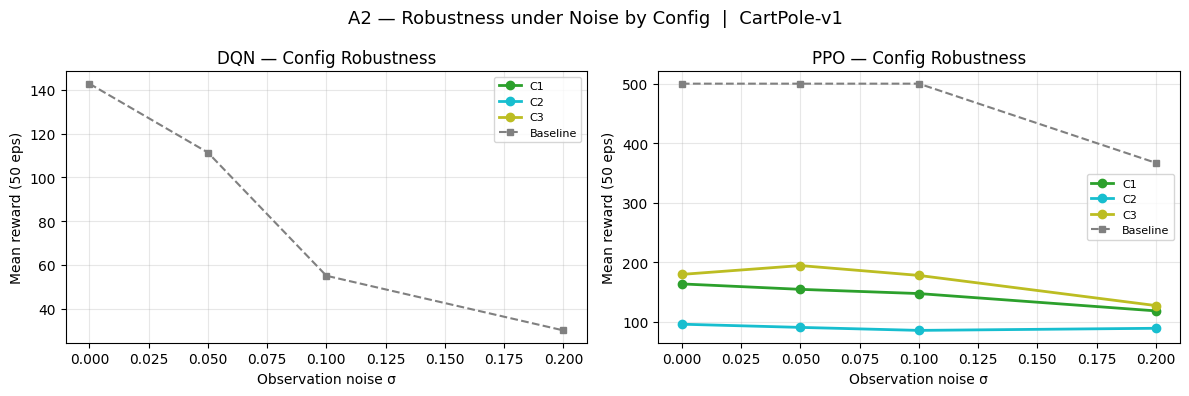

📊 Saved → ablation_plots_CartPole\a2_wm_config_robustness.png


In [7]:
# ── A2 Robustness: how each config degrades under noise ──────────────────────
NOISE_LEVELS = [0.0, 0.05, 0.1, 0.2]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("A2 — Robustness under Noise by Config  |  CartPole-v1", fontsize=13)

for ax, algo in zip(axes, ALGOS):
    for cfg, col, lbl in zip(CONFIGS, cfg_colors, CONFIG_LABELS):
        name   = f"{algo}+Prec C{cfg}"
        means  = [get(name, f"robust_{s}") for s in NOISE_LEVELS]
        ax.plot(NOISE_LEVELS, means, color=col, marker='o',
                linewidth=2, markersize=6, label=f"C{cfg}")
    # Baseline
    bl_means = [get(f"{algo} baseline", f"robust_{s}") for s in NOISE_LEVELS]
    ax.plot(NOISE_LEVELS, bl_means, color='grey', marker='s',
            linewidth=1.5, linestyle='--', markersize=5, label="Baseline")
    ax.set_xlabel("Observation noise σ")
    ax.set_ylabel("Mean reward (50 eps)")
    ax.set_title(f"{algo} — Config Robustness")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
path = os.path.join(PLOT_DIR, "a2_wm_config_robustness.png")
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Saved → {path}")


## 4. Ablation A3 — Verification Strategy

**Question:** Does the verification strategy matter, and does lookahead add value over safety-only?

This ablation requires re-running **one** agent (DQN + best WM config) with three strategies:
`safety`, `lookahead`, `combined`

**Two options:**
- If you already ran these variants → load from JSON (update `STRATEGY_RESULTS_JSON` below)
- Otherwise → run the quick training block at the bottom of this cell

> For CartPole, the `lookahead` check uses Gaussian perturbation variance —
> `combined` adds it on top of safety. The key question is whether the extra
> compute cost of perturbation testing justifies any reward/robustness gain.

In [13]:
# ── Option A: load from saved results if available ───────────────────────────
STRATEGY_RESULTS_JSON = "ablation_plots_CartPole/a3_strategy_results.json"

strategy_results = None
if os.path.exists(STRATEGY_RESULTS_JSON):
    with open(STRATEGY_RESULTS_JSON) as f:
        strategy_results = json.load(f)
    print(f"✅ Strategy results loaded from {STRATEGY_RESULTS_JSON}")
else:
    print(f"⚠️  {STRATEGY_RESULTS_JSON} not found.")
    print(f"   Run the training block below (Cell A3-Train) to generate it.")
    print(f"   Or skip to A3 analysis if you already have results in the eval JSON.")


✅ Strategy results loaded from ablation_plots_CartPole/a3_strategy_results.json


In [14]:
# ── Option B: quick training — run only if JSON not found ────────────────────
# This trains DQN + best WM config with each of the 3 strategies.
# Uses fewer episodes than the main training (200 eps) for speed.
# Skip this cell if strategy_results is already loaded above.

if strategy_results is None:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    import gymnasium as gym
    import random
    from collections import deque

    DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ENV_NAME = "CartPole-v1"
    SEED     = 42
    A3_EPS   = 200           # episodes per strategy — enough to see convergence
    A3_EVAL  = 50            # greedy eval episodes after training

    # ── Minimal DQN for ablation (same architecture as training) ──────────────
    class QNet(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(4,64), nn.ReLU(),
                nn.Linear(64,64), nn.ReLU(),
                nn.Linear(64,2)
            )
        def forward(self, x): return self.net(x)

    class ReplayBuffer:
        def __init__(self, cap=40000):
            self.buf = deque(maxlen=cap)
        def push(self, s,a,r,ns,d): self.buf.append((s,a,r,ns,d))
        def sample(self, n):
            b = random.sample(self.buf, n)
            s,a,r,ns,d = zip(*b)
            return (torch.FloatTensor(np.array(s)).to(DEVICE),
                    torch.LongTensor(a).to(DEVICE),
                    torch.FloatTensor(r).to(DEVICE),
                    torch.FloatTensor(np.array(ns)).to(DEVICE),
                    torch.FloatTensor(d).to(DEVICE))
        def __len__(self): return len(self.buf)

    # ── Minimal ActionVerifier for CartPole ───────────────────────────────────
    # Load the best world model config found in A2
    import sys, os
    sys.path.insert(0, "..")

    # Identify best config from eval results
    best_cfg = max([1,2,3],
        key=lambda c: get(f"DQN+Prec C{c}", "mean_reward"))
    print(f"Using best WM config: C{best_cfg}")

    # Load WM checkpoint
    WM_DIR = "checkpoints_dqn_precedence_CartPole"

    class WorldModel(nn.Module):
        def __init__(self, state_dim=4, act_dim=2, config=1, n_step=1, hidden=32):
            super().__init__()
            in_dim = state_dim + (n_step*act_dim if config==2 else act_dim)
            self.config = config
            self.net = nn.Sequential(
                nn.Linear(in_dim,hidden), nn.ReLU(),
                nn.Linear(hidden,hidden), nn.ReLU(),
                nn.Linear(hidden,state_dim))
        def forward(self, s, a): return self.net(torch.cat([s,a],dim=-1))
        def predict(self, s, a):
            out = self.forward(s,a)
            return s + out if self.config == 3 else out

    def load_wm(cfg):
        tag  = f"config{cfg}" + ("_n2" if cfg==2 else "")
        path = os.path.join(WM_DIR, f"wm_{ENV_NAME}_{tag}.pt")
        if not os.path.exists(path):
            # fallback naming
            path = os.path.join("checkpoints_compare", f"Tiny_seed0.pth")
        if os.path.exists(path):
            m = WorldModel(config=cfg).to(DEVICE)
            ck = torch.load(path, map_location=DEVICE, weights_only=False)
            sd = ck.get("state_dict", ck)
            try: m.load_state_dict(sd); m.eval()
            except: pass
            return m
        return None

    wm = load_wm(best_cfg)

    # ── Verification (simplified, same logic as training) ─────────────────────
    POLE_SAFE = 0.2
    CART_SAFE = 2.0

    def one_hot(a, n=2):
        oh = np.zeros(n, dtype=np.float32); oh[a]=1.0; return oh

    def verify(s_np, action, strategy, q_net, wm, mean, std):
        if wm is None: return True
        s_norm = (s_np - mean) / (std + 1e-8)
        s_t = torch.FloatTensor(s_norm).unsqueeze(0).to(DEVICE)
        a_t = torch.FloatTensor(one_hot(action)).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            s2 = wm.predict(s_t, a_t).cpu().numpy()[0]
        s2_raw = s2 * std + mean

        safety_ok = (abs(s2_raw[0]) < CART_SAFE and abs(s2_raw[2]) < POLE_SAFE)
        if strategy == 'safety': return safety_ok
        if not safety_ok and strategy == 'combined': return False

        # Stability: variance under 5 small perturbations
        preds = []
        for i in range(5):
            noise = np.random.randn(4).astype(np.float32)*0.01 if i>0 else 0
            sn = ((s_np + noise) - mean)/(std+1e-8)
            st = torch.FloatTensor(sn).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                p = wm.predict(st, a_t).cpu().numpy()[0]
            preds.append(p)
        var = float(np.mean(np.var(np.array(preds), axis=0)))
        stab_ok = var < 0.5
        if strategy == 'lookahead': return stab_ok
        return safety_ok and stab_ok   # combined

    # ── Load normalisation stats ──────────────────────────────────────────────
    try:
        sc   = np.load("../data/collected/CartPole/scaler.npz")
        mean = sc["state_mean"].astype(np.float32)
        std  = sc["state_std"].astype(np.float32)
    except Exception:
        mean = np.zeros(4, dtype=np.float32)
        std  = np.ones(4,  dtype=np.float32)

    # ── Training loop ─────────────────────────────────────────────────────────
    def run_strategy(strategy, n_eps=A3_EPS):
        env      = gym.make(ENV_NAME)
        q_net    = QNet().to(DEVICE)
        target   = QNet().to(DEVICE)
        target.load_state_dict(q_net.state_dict())
        opt      = optim.Adam(q_net.parameters(), lr=3e-4)
        replay   = ReplayBuffer()
        eps_val  = 1.0
        rewards  = []

        for ep in range(n_eps):
            obs, _ = env.reset(seed=SEED+ep)
            ep_r, done = 0.0, False
            while not done:
                if np.random.rand() < eps_val:
                    a = env.action_space.sample()
                else:
                    with torch.no_grad():
                        a = int(q_net(torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)).argmax())

                if wm is not None:
                    is_valid = verify(obs, a, strategy, q_net, wm, mean, std)
                    if not is_valid:
                        alt = 1 - a
                        if verify(obs, alt, strategy, q_net, wm, mean, std):
                            a = alt

                ns, r, term, trunc, _ = env.step(a)
                done = term or trunc
                replay.push(obs, a, r, ns, float(done))
                obs = ns; ep_r += r

                if len(replay) >= 64:
                    s,ac,rw,nss,d = replay.sample(64)
                    qv = q_net(s).gather(1,ac.unsqueeze(1)).squeeze(1)
                    with torch.no_grad():
                        tgt = rw + 0.99*target(nss).max(1)[0]*(1-d)
                    loss = nn.MSELoss()(qv, tgt)
                    opt.zero_grad(); loss.backward(); opt.step()

            rewards.append(ep_r)
            eps_val = max(0.02, eps_val*0.995)
            if (ep+1)%50==0:
                print(f"  [{strategy}] ep {ep+1}  mean25={np.mean(rewards[-25:]):.1f}")
            if ep%300==0: target.load_state_dict(q_net.state_dict())

        env.close()

        # Greedy eval
        eval_env = gym.make(ENV_NAME)
        eval_r   = []
        q_net.eval()
        for i in range(A3_EVAL):
            obs,_ = eval_env.reset(seed=SEED+500+i)
            ep_r, done = 0.0, False
            while not done:
                with torch.no_grad():
                    a = int(q_net(torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)).argmax())
                obs,r,t,tr,_ = eval_env.step(a)
                done=t or tr; ep_r+=r
            eval_r.append(ep_r)
        eval_env.close()

        return {
            "strategy"   : strategy,
            "rewards"    : rewards,
            "eval_mean"  : float(np.mean(eval_r)),
            "eval_std"   : float(np.std(eval_r)),
            "train_std"  : float(np.std(rewards[-50:])),
            "episodes_to_solve": next(
                (i+1 for i in range(24,len(rewards))
                 if np.mean(rewards[i-24:i+1])>=SOLVE_THRESH), -1)
        }

    np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED)
    strategy_results = {}
    for strat in ["safety", "lookahead", "combined"]:
        print(f"\n▶ Training strategy: {strat}")
        strategy_results[strat] = run_strategy(strat)

    os.makedirs(PLOT_DIR, exist_ok=True)
    with open(STRATEGY_RESULTS_JSON, "w") as f:
        sr_save = {k: {kk:vv for kk,vv in v.items() if kk!="rewards"}
                   for k,v in strategy_results.items()}
        for k,v in strategy_results.items():
            sr_save[k]["rewards"] = [float(r) for r in v["rewards"]]
        json.dump(sr_save, f, indent=4)
    print(f"\n✅ Strategy results saved → {STRATEGY_RESULTS_JSON}")


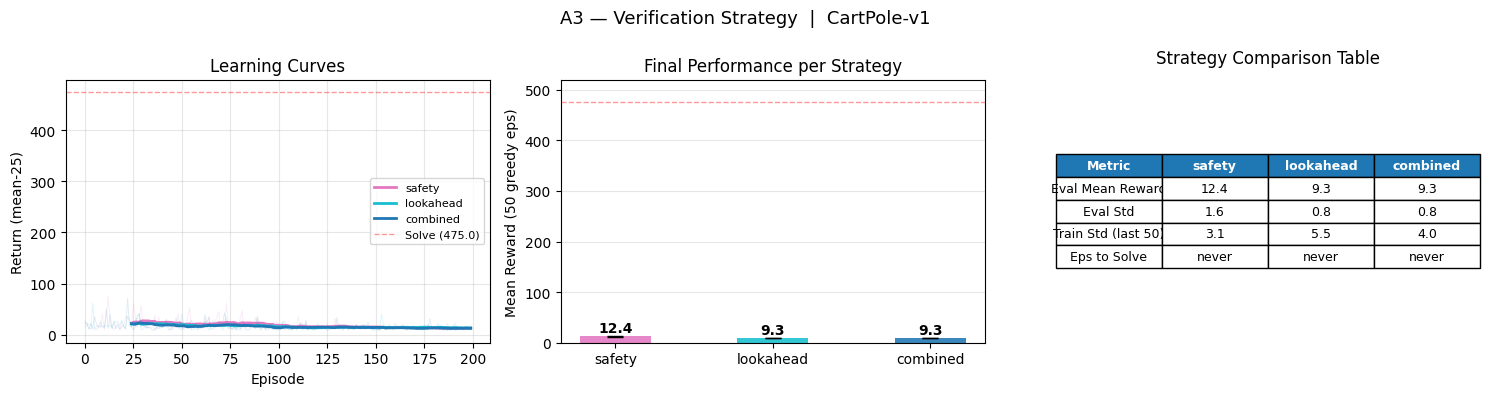

📊 Saved → ablation_plots_CartPole\a3_verification_strategy.png


In [15]:
# ── A3 Analysis & plots ───────────────────────────────────────────────────────
if strategy_results is None:
    print("⚠️  No strategy results — run the training cell above first.")
else:
    STRATEGIES  = ["safety", "lookahead", "combined"]
    STRAT_COLORS= ["#e377c2", "#17becf", "#1f77b4"]
    WINDOW      = 25

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("A3 — Verification Strategy  |  CartPole-v1", fontsize=13)

    # ── Learning curves ───────────────────────────────────────────────
    ax = axes[0]
    for s, col in zip(STRATEGIES, STRAT_COLORS):
        rw = np.array(strategy_results[s]["rewards"])
        ax.plot(rw, alpha=0.15, color=col, linewidth=0.6)
        if len(rw) >= WINDOW:
            ma = np.convolve(rw, np.ones(WINDOW)/WINDOW, mode='valid')
            ax.plot(np.arange(WINDOW-1,len(rw)), ma,
                    color=col, linewidth=2, label=s)
    ax.axhline(SOLVE_THRESH, color='red', linestyle='--',
               alpha=0.4, linewidth=1, label=f'Solve ({SOLVE_THRESH})')
    ax.set_xlabel("Episode"); ax.set_ylabel("Return (mean-25)")
    ax.set_title("Learning Curves"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # ── Eval mean reward bar ──────────────────────────────────────────
    ax = axes[1]
    eval_means = [strategy_results[s]["eval_mean"] for s in STRATEGIES]
    eval_stds  = [strategy_results[s]["eval_std"]  for s in STRATEGIES]
    bars = ax.bar(STRATEGIES, eval_means, yerr=eval_stds, capsize=6,
                  color=STRAT_COLORS, alpha=0.88, width=0.45)
    for bar, val in zip(bars, eval_means):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+3,
                f"{val:.1f}", ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.axhline(SOLVE_THRESH, color='red', linestyle='--',
               alpha=0.4, linewidth=1)
    ax.set_ylim(0,520)
    ax.set_ylabel(f"Mean Reward ({A3_EVAL} greedy eps)")
    ax.set_title("Final Performance per Strategy")
    ax.grid(axis='y', alpha=0.3)

    # ── Delta table: combined vs safety-only ──────────────────────────
    ax = axes[2]
    ax.axis('off')
    rows_t = [["Metric", "safety", "lookahead", "combined"]]
    for metric, label in [
        ("eval_mean",  "Eval Mean Reward"),
        ("eval_std",   "Eval Std"),
        ("train_std",  "Train Std (last 50)"),
        ("episodes_to_solve", "Eps to Solve"),
    ]:
        row = [label]
        for s in STRATEGIES:
            v = strategy_results[s].get(metric, float('nan'))
            row.append(f"{v:.1f}" if not np.isnan(float(v if v!=-1 else float('nan'))) and v!=-1
                       else ("never" if metric=="episodes_to_solve" else "N/A"))
        rows_t.append(row)

    tbl = ax.table(cellText=rows_t[1:], colLabels=rows_t[0],
                   loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(9)
    tbl.scale(1, 1.6)
    # Highlight header
    for j in range(4):
        tbl[0,j].set_facecolor('#1f77b4')
        tbl[0,j].set_text_props(color='white', fontweight='bold')
    ax.set_title("Strategy Comparison Table", pad=12)

    plt.tight_layout()
    path = os.path.join(PLOT_DIR, "a3_verification_strategy.png")
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"📊 Saved → {path}")


## 5. Combined Summary — All Ablations

In [16]:
print(f"\n{'='*70}")
print(f"  ABLATION STUDY SUMMARY — CartPole-v1")
print(f"{'='*70}\n")

# A1: effect of precedence
print("A1 — PRECEDENCE ON vs OFF")
print("-"*50)
for baseline, prec, algo in pairs:
    if prec is None: continue
    delta = get(prec,"mean_reward") - get(baseline,"mean_reward")
    sign  = "✅" if delta > 0 else "❌"
    print(f"  {algo}: {get(baseline,'mean_reward'):.1f} → {get(prec,'mean_reward'):.1f}  "
          f"(Δ={delta:+.1f}) {sign}")

# A2: best config
print("\nA2 — BEST WORLD MODEL CONFIG")
print("-"*50)
for algo in ALGOS:
    vals = {f"C{c}": get(f"{algo}+Prec C{c}","mean_reward") for c in CONFIGS}
    best = max(vals, key=vals.get)
    print(f"  {algo}: best={best} ({vals[best]:.1f})  |  "
          + "  ".join(f"{k}={v:.1f}" for k,v in vals.items()))

# A3: best strategy
print("\nA3 — BEST VERIFICATION STRATEGY")
print("-"*50)
if strategy_results:
    for s in STRATEGIES:
        m = strategy_results[s].get("eval_mean", float('nan'))
        e = strategy_results[s].get("episodes_to_solve", -1)
        print(f"  {s:<12}: eval_mean={m:.1f}  eps_to_solve={e if e>0 else 'never'}")
else:
    print("  Not run yet — execute Cell A3-Train first.")

print(f"\n✅ Ablation complete. Plots saved in: {PLOT_DIR}/")



  ABLATION STUDY SUMMARY — CartPole-v1

A1 — PRECEDENCE ON vs OFF
--------------------------------------------------
  PPO: nan → nan  (Δ=+nan) ❌

A2 — BEST WORLD MODEL CONFIG
--------------------------------------------------
  DQN: best=C1 (nan)  |  C1=nan  C2=nan  C3=nan
  PPO: best=C1 (nan)  |  C1=nan  C2=nan  C3=nan

A3 — BEST VERIFICATION STRATEGY
--------------------------------------------------
  safety      : eval_mean=12.4  eps_to_solve=never
  lookahead   : eval_mean=9.3  eps_to_solve=never
  combined    : eval_mean=9.3  eps_to_solve=never

✅ Ablation complete. Plots saved in: ablation_plots_CartPole/


In [17]:
# ── Save ablation summary JSON ────────────────────────────────────────────────
ablation_summary = {
    "env"          : "CartPole-v1",
    "A1_precedence": {
        algo: {
            "baseline_mean"   : get(bl,  "mean_reward"),
            "prec_mean"       : get(pr,  "mean_reward"),
            "delta"           : get(pr,"mean_reward") - get(bl,"mean_reward"),
            "best_config"     : pr,
        }
        for bl, pr, algo in pairs if pr is not None
    },
    "A2_wm_config" : {
        algo: {
            f"C{c}": {
                "mean_reward"       : get(f"{algo}+Prec C{c}", "mean_reward"),
                "std_reward"        : get(f"{algo}+Prec C{c}", "std_reward"),
                "episodes_to_solve" : get(f"{algo}+Prec C{c}", "episodes_to_solve"),
                "robust_0.1"        : get(f"{algo}+Prec C{c}", "robust_0.1"),
            }
            for c in CONFIGS
        }
        for algo in ALGOS
    },
    "A3_strategy"  : {
        s: {k: v for k,v in strategy_results[s].items() if k != "rewards"}
        for s in STRATEGIES
    } if strategy_results else {},
}

out = os.path.join(PLOT_DIR, "cartpole_ablation_summary.json")
with open(out, "w") as f:
    json.dump(ablation_summary, f, indent=4)
print(f"✅ Ablation summary saved → {out}")


✅ Ablation summary saved → ablation_plots_CartPole\cartpole_ablation_summary.json
